In [1]:
!pip install -q xgboost shap

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [2]:
def find_file(filename):
    candidates = [
        filename,
        f"/content/{filename}",
        f"/mnt/data/{filename}"
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"{filename} not found. Upload it to Colab.")

train = pd.read_csv(find_file("dataset_Repeat_training.csv"))
test = pd.read_csv(find_file("dataset_Repeat_testing.csv"))

TARGET = "Transported"
ID = "PassengerId"

print("train:", train.shape, "| test:", test.shape)
display(train.head())

train: (5798, 14) | test: (2895, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,2010_01,Earth,True,G/324/P,PSO J318.5-22,33.0,False,0.0,0.0,0.0,0.0,NaN,Candyn Gregordy,True
1,3117_01,Earth,False,F/646/P,TRAPPIST-1e,32.0,False,0.0,0.0,47.0,857.0,23.0,NaN,False
2,5848_01,Earth,False,E/377/S,NaN,28.0,False,229.0,761.0,0.0,0.0,6.0,Eriana Benney,True
3,7785_01,Earth,False,G/1261/S,TRAPPIST-1e,13.0,False,406.0,0.0,52.0,0.0,387.0,Luise Bucklandez,False
4,8375_01,Earth,False,NaN,PSO J318.5-22,15.0,False,64.0,0.0,0.0,0.0,640.0,Carlen Valezaley,True


In [3]:
print("TRAIN INFO")
train.info()

print("\nTEST INFO")
test.info()

print("\nDuplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test :", test.duplicated().sum())
print("Duplicate PassengerIds in train:", train[ID].duplicated().sum())
print("Duplicate PassengerIds in test :", test[ID].duplicated().sum())

display(train.describe(include="all").T)

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5798 entries, 0 to 5797
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   5798 non-null   object 
 1   HomePlanet    5660 non-null   object 
 2   CryoSleep     5657 non-null   object 
 3   Cabin         5663 non-null   object 
 4   Destination   5676 non-null   object 
 5   Age           5678 non-null   float64
 6   VIP           5660 non-null   object 
 7   RoomService   5679 non-null   float64
 8   FoodCourt     5682 non-null   float64
 9   ShoppingMall  5668 non-null   float64
 10  Spa           5675 non-null   float64
 11  VRDeck        5665 non-null   float64
 12  Name          5655 non-null   object 
 13  Transported   5798 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 594.7+ KB

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2895 entries, 0 to 2894
Data columns (total 13 columns):
 #   Column  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,5798,5798,1142_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomePlanet,5660,3,Earth,3079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CryoSleep,5657,2,False,3633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cabin,5663,4659,C/21/P,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,5676,3,TRAPPIST-1e,3949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5678.0,NaN,NaN,NaN,28.877598,14.561429,0.0,19.0,27.0,38.0,78.0
VIP,5660,2,False,5523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RoomService,5679.0,NaN,NaN,NaN,218.186124,647.070964,0.0,0.0,0.0,42.0,9920.0
FoodCourt,5682.0,NaN,NaN,NaN,455.892819,1606.591863,0.0,0.0,0.0,82.0,29813.0
ShoppingMall,5668.0,NaN,NaN,NaN,169.183663,616.175949,0.0,0.0,0.0,25.0,23492.0


,Count,Percent
Transported,,
True,2923,50.41
False,2875,49.59


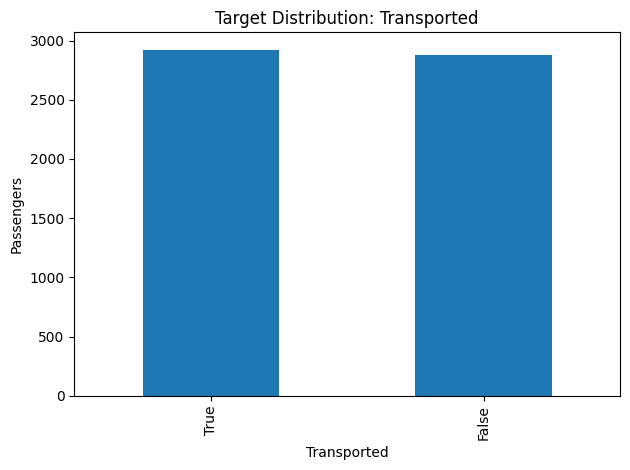

In [4]:
target_summary = pd.DataFrame({
    "Count": train[TARGET].value_counts(),
    "Percent": (train[TARGET].value_counts(normalize=True) * 100).round(2)
})
display(target_summary)

train[TARGET].value_counts().plot(kind="bar")
plt.title("Target Distribution: Transported")
plt.xlabel("Transported")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

,Missing_Count,Missing_Percent
Name,143,2.47
CryoSleep,141,2.43
VIP,138,2.38
HomePlanet,138,2.38
Cabin,135,2.33
VRDeck,133,2.29
ShoppingMall,130,2.24
Spa,123,2.12
Destination,122,2.10
Age,120,2.07


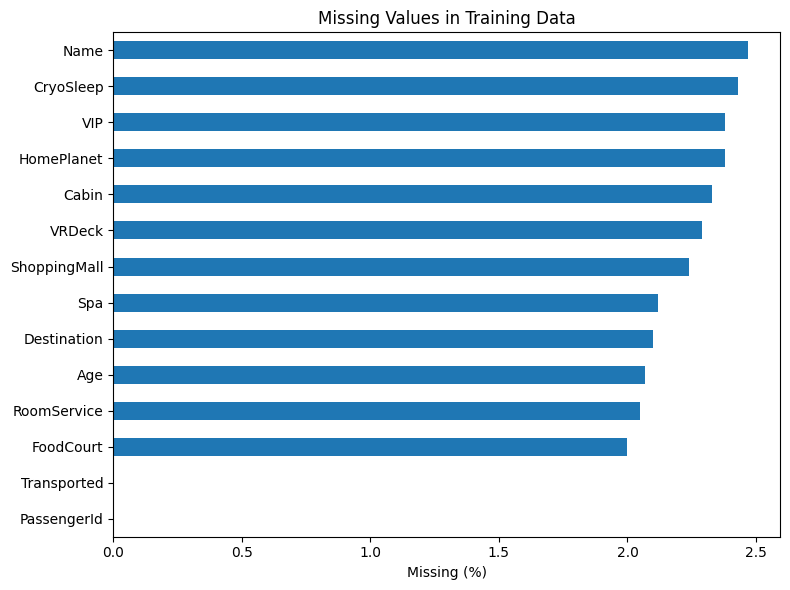

In [5]:
missing_summary = pd.DataFrame({
    "Missing_Count": train.isna().sum(),
    "Missing_Percent": (train.isna().mean() * 100).round(2)
}).sort_values("Missing_Percent", ascending=False)

display(missing_summary)

missing_summary["Missing_Percent"].sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Missing Values in Training Data")
plt.xlabel("Missing (%)")
plt.tight_layout()
plt.show()